<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #4f46e5; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Algoritmos de Búsqueda: Fundamentos de la Búsqueda No Informada 🧭
      </h1>
      <p style="margin: 6px 0 0 0; color: #4f46e5; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Introducción a la Inteligencia Artificial
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #4f46e5; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 04 • Algoritmos de Búsqueda
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #4f46e5; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

---
## 1. Los Algoritmos de Búsqueda en Inteligencia Artificial 🔎

Gran parte de los problemas clásicos de la Inteligencia Artificial pueden reformularse como un **problema de búsqueda**: un agente parte de un **estado inicial**, dispone de un conjunto de **acciones** que lo llevan a nuevos **estados**, y debe encontrar una secuencia de acciones que lo lleve a un **estado meta** (*goal state*).

A lo largo de este módulo usaremos un caso de uso muy concreto y cotidiano para ilustrar los cuatro algoritmos de búsqueda clásicos: **encontrar un archivo específico dentro del sistema de directorios de una empresa**, sin usar el buscador del sistema operativo, sino programando nosotros mismos el algoritmo de búsqueda.

> 🏢 **El caso de estudio (el mismo en los 4 cuadernos de este módulo):** la empresa ficticia *Constructora Horizonte Andino S.A.S.* guarda todos sus documentos en un servidor central organizado en carpetas y subcarpetas. Un ingeniero necesita encontrar el archivo **`informe_final.pdf`** del Proyecto Norte, pero no recuerda en qué subcarpeta quedó guardado. Nuestro agente de búsqueda deberá recorrer el árbol de carpetas hasta encontrarlo.

| Elemento del problema | Su equivalente en "buscar un archivo" |
|---|---|
| **Estado** | Una carpeta o archivo específico del servidor |
| **Estado inicial** | La carpeta raíz del servidor (`ServidorCentral`) |
| **Acciones / Función sucesora** | "Entrar" a cada subcarpeta o archivo contenido en la carpeta actual |
| **Estado meta** | El nodo cuyo nombre coincide con `informe_final.pdf` |
| **Prueba de objetivo (*goal test*)** | ¿El nombre del nodo actual es igual al nombre del archivo que buscamos? |
| **Costo de la ruta** | Número de "saltos" (carpetas atravesadas) hasta llegar al archivo |

---
## 2. Conceptos Clave: Frontera, Nodo Explorado y Estado Meta (1.16.1) 🧩

Todo algoritmo de búsqueda —informado o no informado— se organiza alrededor de tres estructuras:

| Concepto | Definición | Analogía en nuestro caso de archivos |
|---|---|---|
| **Frontera** (*frontier* / *open list*) | El conjunto de nodos ya **descubiertos** pero **aún no expandidos** (no hemos mirado qué hay dentro de ellos). | Las carpetas que ya vimos en un listado, pero que todavía no hemos abierto. |
| **Nodo explorado** (*explored* / *closed set*) | Un nodo que ya fue **expandido**: ya miramos todo su contenido (sus hijos) y no necesitamos volver a hacerlo. | Una carpeta que ya abrimos y de la que ya anotamos todo lo que contiene. |
| **Estado meta** (*goal state*) | El nodo que satisface la prueba de objetivo: en nuestro caso, el archivo `informe_final.pdf`. | El documento que finalmente estábamos buscando. |
| **Nodo** | Una estructura que envuelve un estado y, típicamente, guarda también el camino recorrido hasta llegar a él. | Una carpeta o archivo, junto con la "ruta" de carpetas que tuvimos que atravesar para llegar a ella. |

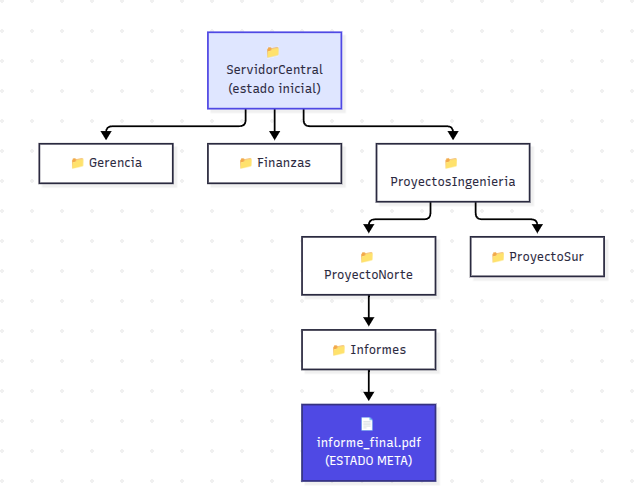

Cada algoritmo de búsqueda se diferencia, esencialmente, en **cómo organiza la frontera** (¿pila?, ¿cola?, ¿cola de prioridad?) y en **qué información usa** para decidir cuál nodo de la frontera expandir a continuación.

In [ ]:
# Representación conceptual simplificada del sistema de archivos.
# (La implementación formal, con una clase Nodo reutilizable, se construye
#  en el siguiente cuaderno: 01_Busqueda_en_Sistemas_de_Archivos_DFS_BFS.ipynb)

sistema_archivos_simplificado = {
    "ServidorCentral": {
        "Gerencia": {"Actas": {}, "Estrategia": {}},
        "Finanzas": {"Contabilidad": {}, "Tesoreria": {}},
        "ProyectosIngenieria": {
            "ProyectoNorte": {"Informes": {"informe_avance_q1.pdf": {}, "informe_final.pdf": {}}},
            "ProyectoSur": {"Informes": {"informe_preliminar.pdf": {}}},
        },
        "RecursosHumanos": {"Nomina": {}, "Contratos": {}},
    }
}

print("Estado inicial (raíz):", list(sistema_archivos_simplificado.keys())[0])
print("Acciones disponibles desde la raíz (hijos directos):",
      list(sistema_archivos_simplificado["ServidorCentral"].keys()))

### 🔬 Simulando manualmente un primer paso de expansión

Antes de escribir un algoritmo completo, veamos "a mano" cómo evolucionan la **frontera** y el conjunto de **explorados** al expandir un único nodo. Esto es exactamente lo que un algoritmo de búsqueda repite una y otra vez hasta encontrar el objetivo (o agotar la frontera).

In [ ]:
frontera = ["ServidorCentral"]
explorados = set()

# Paso 1: sacamos el primer nodo de la frontera y lo "expandimos"
nodo_actual = frontera.pop(0)
explorados.add(nodo_actual)

hijos = list(sistema_archivos_simplificado[nodo_actual].keys())
frontera.extend(hijos)

print(f"Nodo expandido      : {nodo_actual}")
print(f"Nodos explorados     : {explorados}")
print(f"Frontera después     : {frontera}")
print(f"¿Es el objetivo?      : {nodo_actual == 'informe_final.pdf'}")

---
## 3. Búsqueda No Informada versus Búsqueda Informada (1.16.2) 🆚

Los algoritmos de búsqueda se dividen en dos grandes familias, según si usan o no **conocimiento adicional del dominio** para guiar la exploración:

| | **Búsqueda No Informada** (*Uninformed* / *Blind Search*) | **Búsqueda Informada** (*Informed Search*) |
|---|---|---|
| **¿Qué información usa?** | Únicamente la definición del problema: estado inicial, sucesores y prueba de objetivo. | Además, una **función heurística** `h(n)` que estima qué tan "cerca" está un nodo del objetivo. |
| **Algoritmos típicos** | DFS (profundidad), BFS (anchura), Búsqueda de Costo Uniforme. | Greedy Best-First Search (GBFS), A* (A-estrella). |
| **Analogía** | Buscar a ciegas, carpeta por carpeta, sin ninguna pista sobre dónde podría estar el archivo. | Buscar guiándote por pistas: "el archivo se llama *informe*... esta carpeta se llama *Informes*, probablemente sea por aquí". |
| **Eficiencia típica** | Puede explorar muchos nodos irrelevantes antes de llegar al objetivo. | Generalmente explora menos nodos... pero solo si la heurística es buena. |
| **Estudiado en este cuaderno** | ✅ DFS y BFS (cuaderno 01) | ⏭️ GBFS (cuaderno 02) y A* (cuaderno 03) |

En este módulo primero dominaremos la búsqueda no informada (DFS y BFS, cuaderno 01) antes de incorporar heurísticas (GBFS y A*, cuadernos 02 y 03).

---
## 4. El Trade-off entre Memoria y Tiempo: BFS vs. DFS (1.16.3) ⚖️

Antes de implementar nada, conviene entender la diferencia teórica de complejidad entre los dos algoritmos no informados más comunes, en función de:
* `b`: el **factor de ramificación** (cuántos hijos tiene, en promedio, cada nodo).
* `d`: la **profundidad** a la que se encuentra la solución.
* `m`: la profundidad **máxima** del árbol de estados (puede ser mucho mayor que `d`).

| Algoritmo | Estrategia de frontera | Complejidad en Tiempo | Complejidad en Memoria (Espacio) |
|---|---|---|---|
| **BFS** (anchura) | Cola FIFO (primero en entrar, primero en salir) | $O(b^d)$ | $O(b^d)$ — **debe guardar toda la frontera de un nivel completo** |
| **DFS** (profundidad) | Pila LIFO (último en entrar, primero en salir) | $O(b^m)$ | $O(b \cdot m)$ — **solo guarda la rama actual**, mucho más liviano |

**La conclusión práctica:** BFS garantiza encontrar la solución más "cercana" (menos saltos) a la raíz, pero su consumo de memoria puede crecer exponencialmente y volverse inviable en árboles muy anchos. DFS es mucho más económico en memoria, pero puede "perderse" explorando una rama profunda y poco prometedora antes de encontrar la solución (o antes de darse cuenta de que no existe).

In [ ]:
# Ilustración numérica del crecimiento exponencial de la frontera en BFS
# frente al crecimiento lineal (en memoria) de la pila en DFS.

factor_ramificacion = 4   # ej.: cada carpeta tiene en promedio 4 subcarpetas/archivos
profundidad_objetivo = 4  # informe_final.pdf está a 4 saltos de la raíz

print(f"{'Profundidad':<12} | {'Frontera BFS (peor caso, b^d)':<32} | {'Pila DFS (peor caso, b*m)'}")
print("-" * 70)
for d in range(1, profundidad_objetivo + 1):
    frontera_bfs = factor_ramificacion ** d
    pila_dfs = factor_ramificacion * d
    print(f"{d:<12} | {frontera_bfs:<32} | {pila_dfs}")

print("\n💡 A la misma profundidad, BFS puede necesitar guardar miles de nodos en memoria,")
print("   mientras que DFS solo necesita recordar la rama actual (crecimiento lineal).")

---
## 5. Limitaciones y Consideraciones de la Búsqueda No Informada (1.16.4) ⚠️

Ni DFS ni BFS son soluciones universales. Antes de implementarlos formalmente en el próximo cuaderno, es fundamental conocer sus limitaciones:

| Limitación | Descripción | Mitigación habitual |
|---|---|---|
| **Espacios de estados infinitos (o muy grandes)** | Si el árbol de búsqueda es infinito o extremadamente profundo, DFS puede quedar "atrapado" bajando por una rama sin fin, sin nunca hacer *backtrack* hacia el objetivo real. | Establecer un **límite de profundidad** (*Depth-Limited Search*) o usar **Iterative Deepening DFS**, que combina la eficiencia en memoria de DFS con la garantía de encontrar la solución más cercana, como BFS. |
| **Ciclos en el espacio de estados** | Un sistema de archivos "de libro de texto" es un árbol puro (sin ciclos), pero un sistema de archivos **real** puede tener **accesos directos o enlaces simbólicos (*symlinks*)** que apuntan de vuelta a una carpeta ya visitada, generando ciclos. Sin cuidado, el algoritmo podría re-explorar el mismo nodo indefinidamente. | Mantener un **conjunto de nodos explorados** (visto en la Sección 2) y verificar, antes de expandir un nodo, que no haya sido visitado ya. |
| **Ausencia de garantía de optimalidad en DFS** | DFS encuentra *una* solución, no necesariamente la de menor costo o menor número de saltos. | Usar BFS (óptimo si el costo por salto es uniforme) o, mejor aún, algoritmos informados como A* (cuaderno 03). |
| **Ceguera ante el "sentido común"** | Ni DFS ni BFS usan ninguna pista del nombre de la carpeta o archivo: exploran exactamente en el mismo orden sin importar si buscamos `informe_final.pdf` o `presupuesto_anual.xlsx`. | Incorporar una función heurística: esto es exactamente lo que hacen GBFS y A*, que veremos en los cuadernos 02 y 03. |

> 🔮 **Adelanto:** en el cuaderno 03 (Algoritmo A*) extenderemos nuestro sistema de archivos con un **acceso directo real** (un enlace que apunta a una carpeta ya existente desde otro lugar del árbol), precisamente para mostrar en código por qué el manejo cuidadoso de ciclos y la elección del algoritmo correcto son importantes en la práctica.

---
## 📌 Resumen / Puntos Clave

* Muchos problemas de IA se modelan como **búsqueda en un espacio de estados**: estado inicial, función sucesora, prueba de objetivo y costo de ruta.
* Toda búsqueda gira en torno a una **frontera** (nodos descubiertos, no expandidos) y un conjunto de **explorados** (nodos ya expandidos), para evitar trabajo redundante.
* La **búsqueda no informada** (DFS, BFS) sólo usa la definición del problema; la **búsqueda informada** (GBFS, A*) añade una función heurística `h(n)`.
* Existe un **trade-off memoria/tiempo**: BFS es óptimo en número de saltos pero puede consumir memoria exponencial ($O(b^d)$); DFS es económico en memoria ($O(b \cdot m)$) pero no garantiza la solución más corta.
* Los espacios de estados infinitos y los **ciclos** (p. ej. accesos directos en un sistema de archivos real) son limitaciones reales que se mitigan con un conjunto de explorados y, si aplica, un límite de profundidad.
* En el cuaderno 01 implementaremos, con código Python real y ejecutable, DFS y BFS sobre el sistema de archivos simulado de *Constructora Horizonte Andino S.A.S.*

### 🧠 Autoevaluación

1. Explica con tus propias palabras la diferencia entre un nodo en la **frontera** y un nodo **explorado**. ¿Por qué es importante distinguir entre ambos?
2. Si el servidor de la empresa tuviera un factor de ramificación promedio de `b = 10` (10 subcarpetas/archivos por carpeta) y el archivo estuviera a `d = 6` saltos de profundidad, ¿aproximadamente cuántos nodos podría llegar a almacenar la frontera de BFS en el peor caso? ¿Sería viable en la práctica?
3. Describe un escenario real (distinto al de los accesos directos) en el que un espacio de estados podría ser, en la práctica, infinito o excesivamente grande para una búsqueda no informada.
4. ¿En qué se diferencia, conceptualmente, la información que usa DFS/BFS de la que usará GBFS en el próximo cuaderno?

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Introducción a la Inteligencia Artificial — Módulo 04: Algoritmos de Búsqueda</i>
  </p>
</div>